In [1]:
import matplotlib.pyplot as plt
from src.TimeSeriesAnalysis import *
from IPython.display import clear_output
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.lines import Line2D
from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [39]:
results_folder = "../results/TimeSeries/3D"
create_folder(results_folder)

In [ ]:
process_all_roots("../Data/bond_percolation", verbose=True, clean_outputs=False)
summarize_all_dirs("../Data/bond_percolation", verbose=True)
clear_output()

In [3]:
import os, glob, re, json
from pathlib import Path
import numpy as np

L   = 256
DIM = 3
NT  = 3000
K   = 1.0e-06

NC_list  = [2, 4, 8]
RHO_list = [round(1/nc, 2) for nc in NC_list]
compute_means_for_folder(L, DIM, NT, K, NC_list, RHO_list)

[OK] Salvo: ../Data/bond_percolation/num_colors_2/dim_3/L_256/NT_constant/NT_3000/k_1.0e-06/rho_5.0000e-01/all_data_bundle.json
[OK] Salvo: ../Data/bond_percolation/num_colors_4/dim_3/L_256/NT_constant/NT_3000/k_1.0e-06/rho_2.5000e-01/all_data_bundle.json
[OK] Salvo: ../Data/bond_percolation/num_colors_8/dim_3/L_256/NT_constant/NT_3000/k_1.0e-06/rho_1.2000e-01/all_data_bundle.json


In [51]:
df = pd.read_csv("../Data/bond_percolation/all_data_3D.dat", sep=' ').sort_values('rho')
df

,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
3174,512,3000,0.000001,2,0.011030,1.0,0.1,1,50,0.250182,0.000059,2850.780,29.863066,9539302.540,74998.156117
3175,512,3000,0.000001,2,0.011030,1.0,0.1,2,50,0.250117,0.000059,2955.000,24.991884,9540105.360,75031.676194
2872,512,3000,0.000001,2,0.013538,1.0,0.1,1,50,0.250046,0.000060,2803.360,28.682509,9373935.240,81298.242872
2873,512,3000,0.000001,2,0.013538,1.0,0.1,2,50,0.250218,0.000058,2899.700,27.087119,9374516.820,81230.615244
3082,512,3000,0.000001,2,0.016045,1.0,0.1,1,50,0.250156,0.000059,2891.320,27.316773,9633124.940,77766.680260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3363,128,3000,0.000001,2,0.497490,1.0,0.1,2,500,0.368663,0.000480,144.844,0.203219,992574.624,3070.589961
2542,256,3000,0.000001,2,0.500000,1.0,0.1,1,100,0.256731,0.000062,790.800,1.962631,3117258.750,5640.954449
3278,128,3000,0.000001,2,0.500000,1.0,0.1,1,500,0.556922,0.000929,144.390,0.165658,897404.110,2668.764902
2543,256,3000,0.000001,2,0.500000,1.0,0.1,2,100,0.256894,0.000067,798.020,1.846590,3117092.460,5648.742550


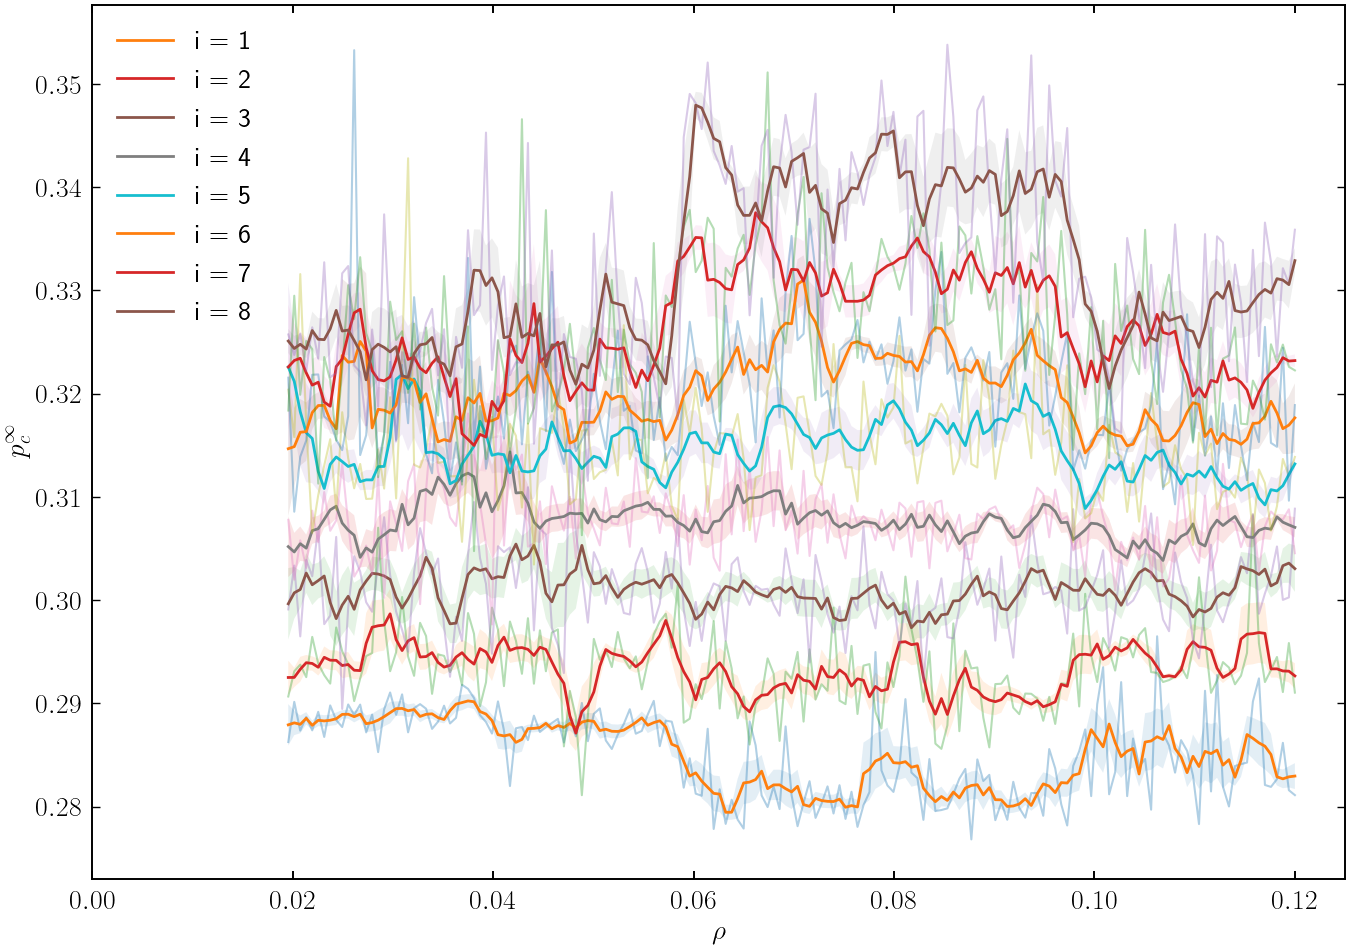

In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L = 256
nc = 8
orders = [i for i in range(1, nc+1)]

WINDOW = 5  # nº de pontos na janela (ajuste conforme quiser)

#plt.figure(figsize=(10,4))

for order in orders:
    df_f = df[(df["L"] == L) & (df["nc"] == nc) & (df["order"] == order)].copy()
    df_f = df_f.sort_values("rho")  # garante ordem crescente no eixo x

    x = df_f["rho"].to_numpy()
    y = df_f["p_mean"].to_numpy()

    # média móvel centrada
    y_ma = (
        pd.Series(y)
        .rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2))
        .mean()
        .to_numpy()
    )

    # desvio padrão na janela e erro padrão da média
    y_std = (
        pd.Series(y)
        .rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2))
        .std()
        .to_numpy()
    )
    y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y)+1)))  # aproxima

    # série original (mais clarinha) + média móvel
    plt.plot(x, y, alpha=0.35)
    plt.plot(x, y_ma, linewidth=2, label=f"i = {order}")

    # faixa opcional de incerteza (comente se não quiser)
    plt.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)

plt.legend()
plt.xlabel(r"$\rho$")
#plt.axhline(y=0.24881182, xmin=0, xmax=0.5)
plt.ylabel(r"$p_c^{\infty}$")
plt.xlim([0, 1/nc ])
plt.tight_layout()
plt.show()

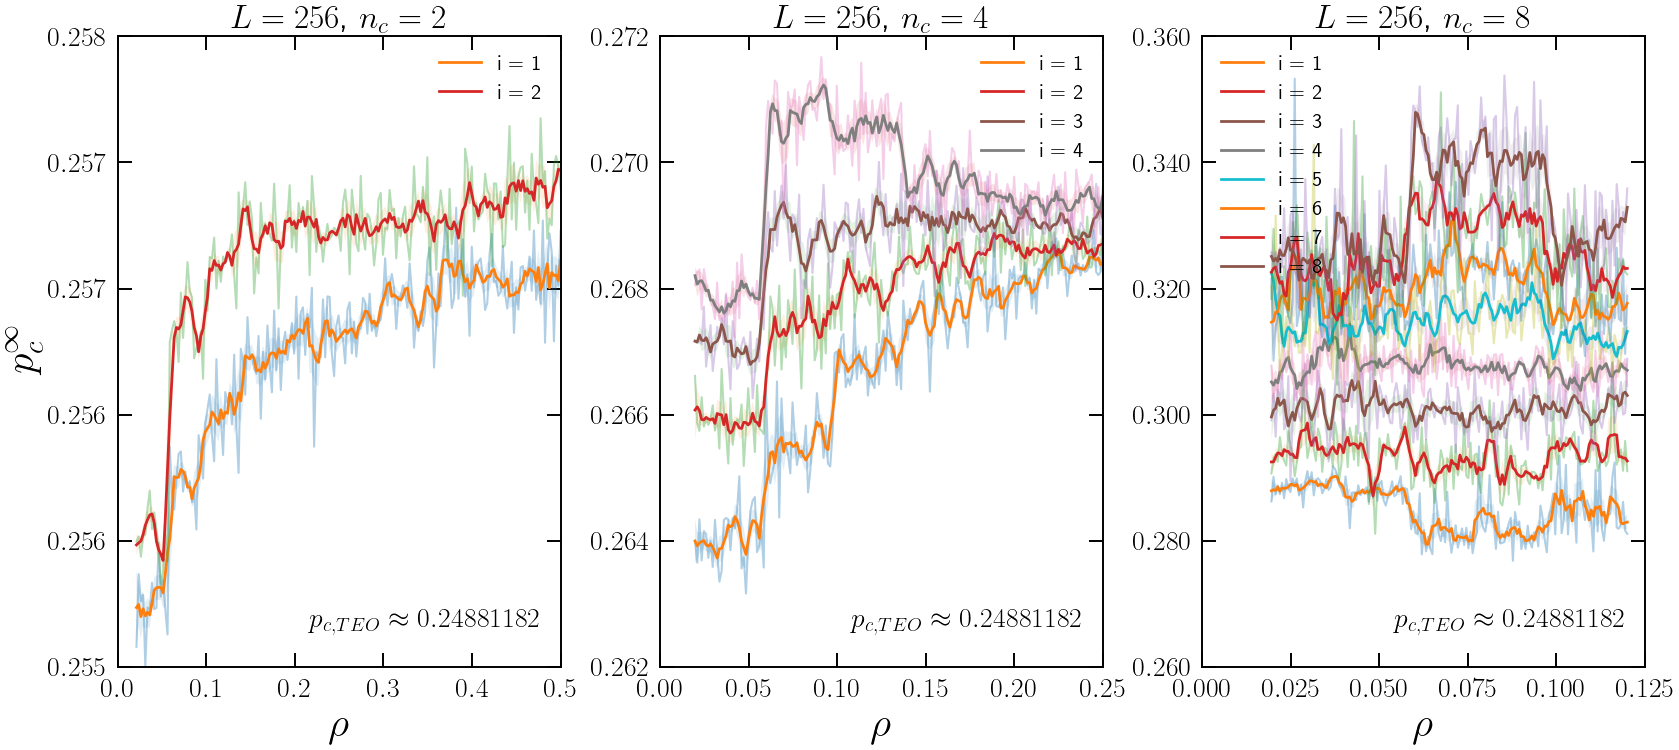

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L = 256
NC_LIST = [2, 4, 8]
WINDOW = 5

ylims = [(0.2550, 0.2575), (0.262, 0.272), (0.26, 0.36)]

fig, axes = plt.subplots(1, 3, figsize=(17, 8), sharey=False)   # <<-- sem sharey
thickness_axes = 1.4
for ax, nc, ylim in zip(axes, NC_LIST, ylims):
    orders = [i for i in range(1, nc+1)]

    for order in orders:
        df_f = df[(df["L"] == L) & (df["nc"] == nc) & (df["order"] == order)].copy()
        if df_f.empty:
            continue
        df_f = df_f.sort_values("rho")

        x = df_f["rho"].to_numpy()
        y = df_f["p_mean"].to_numpy()

        y_ma = (
            pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2)).mean().to_numpy()
        )
        y_std = (
            pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2)).std().to_numpy()
        )
        y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y)+1)))

        ax.plot(x, y, alpha=0.35)
        ax.plot(x, y_ma, linewidth=2, label=f"i = {order}")
        ax.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)

    # limites e ticks específicos por painel
    ax.set_ylim(ylim)
    yticks = np.linspace(ylim[0], ylim[1], 6)           # ajuste o número de ticks se quiser
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"${t:.3f}$" for t in yticks])
    
    ax.set_title(rf"$L = {L}$, $n_c = {nc}$")
    ax.set_xlabel(r"$\rho$",fontsize=30)
    ax.set_xlim([0, 1/nc])
    ax.legend(fontsize=15)
    ax.tick_params(axis='both', which='major', direction='in', length=10, width=thickness_axes, labelsize=20)
    for spine in ax.spines.values():
        spine.set_linewidth(thickness_axes)
    ax.text(
        0.95, 0.05,               # (x,y) no sistema [0..1] do eixo
        r"$p_{c,TEO} \approx 0.24881182$",
        transform=ax.transAxes, # usa coords do eixo
        ha="right", va="bottom",
        fontsize=20,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)  # opcional
    )
axes[0].set_ylabel(r"$p_c^{\infty}$",fontsize=30)
fig.tight_layout()
plt.savefig(results_folder + "/pc_multi_L_nc.pdf")
plt.show()


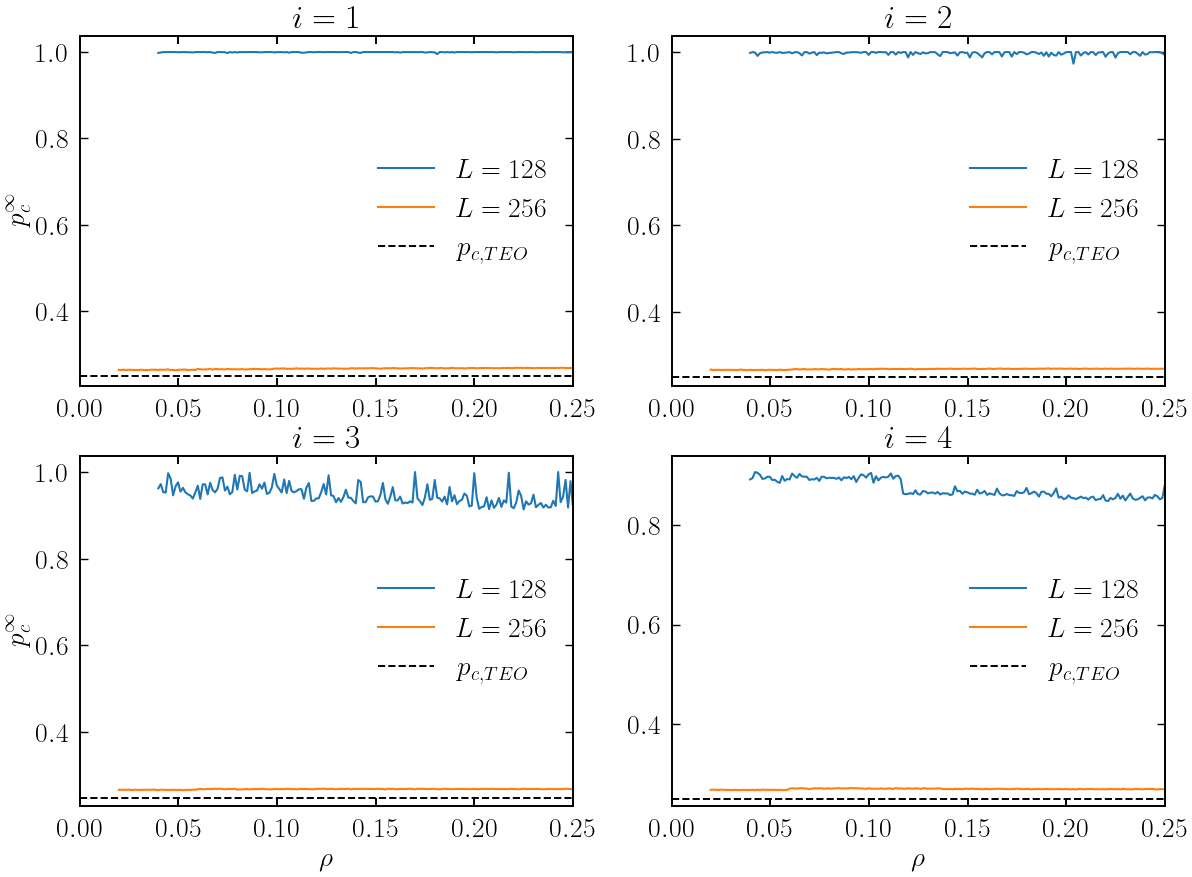

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L = [128, 256]
Nc = 4
WINDOW = 5
orders = [i for i in range(1,5)]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
thickness_axes = 1.4
axs = [ax for ax in axes.flatten()]
df_filter = df[(df["nc"]==4) & (df["p0"]==1.0)]

for idx, ord in enumerate(orders):
    for l in L:
        df_ = df_filter[(df_filter["order"]==ord) & (df_filter["L"] == l)]
        axs[idx].plot(df_['rho'], df_['p_mean'], label=f'$L = {l}$')

for idx, ax in enumerate(axs):
    ax.set_xlim(0, 0.25)
    ax.set_title(f"$i={idx+1}$")
    ax.axhline(y=0.24881182, xmin=0, xmax=1, color='k', ls='--', lw=1.4 ,label=r'$p_{c,TEO}$')
    ax.legend()

for ax in axes[:,0]:
    ax.set_ylabel(r"$p_c^\infty$", fontsize=20)
for ax in axes[1,:]:
    ax.set_xlabel(r"$\rho$", fontsize=20)
plt.show()

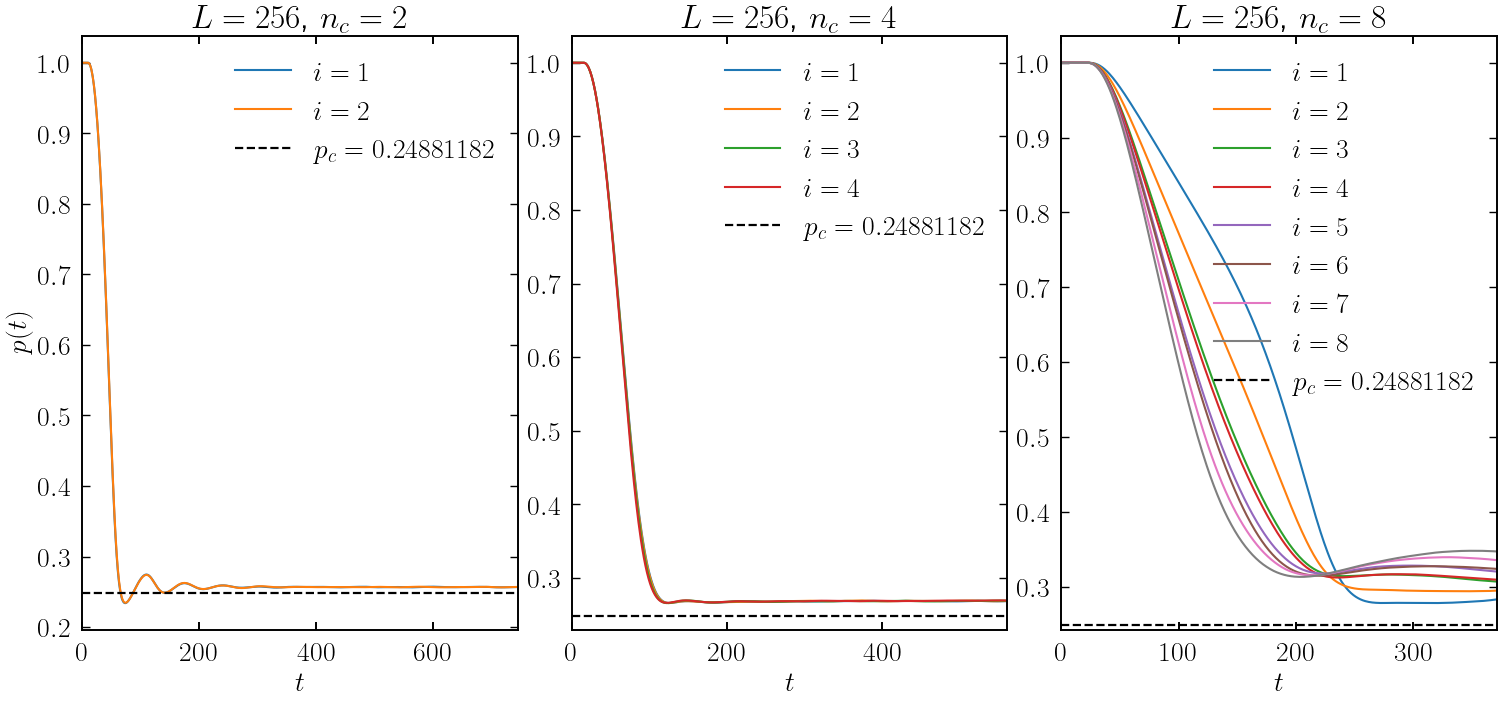

In [40]:
NC_LST = [2, 4, 8]
RHO_LST = [round(1/nc,2) for nc in NC_LST]
p0 = 1.0
L = 256


fig, axs = plt.subplots(1, 3, figsize=(15, 7), constrained_layout=True)
count = 0
for nc, rho in zip(NC_LST, RHO_LST):
    filename = f"../Data/bond_percolation/num_colors_{nc}/dim_3/L_{L}/NT_constant/NT_3000/k_1.0e-06/rho_{rho:.4e}/all_data_bundle.json"
    bundle, df = read_all_data_bundle(filename, as_dataframe=True)
    orders = df['order'].unique()
    x_max = 0
    for idx, ord in enumerate(orders):
        df_filter = df[df['order']==ord]
        axs[count].plot(df_filter['t'], df_filter['pt'],label=f'$i = {idx+1}$')
    
        if(x_max < max(df_filter['t'])):
            x_max = max(df_filter['t'])
        
    axs[count].set_title(f"$L = {L}$, $n_c = {nc}$")
    axs[count].set_xlim(0, int(x_max))
    axs[count].axhline(y=0.24881182,xmax=int(x_max),xmin=0, ls='--', lw='1.6', color='k' ,label=r'$p_c = 0.24881182$')
    count += 1

for ax in axs:
    ax.set_xlabel('$t$')
    
    ax.legend()
axs[0].set_ylabel('$p(t)$')
plt.savefig(results_folder + f"/pt_series_L_{L}_without_zoom.pdf")
plt.show()

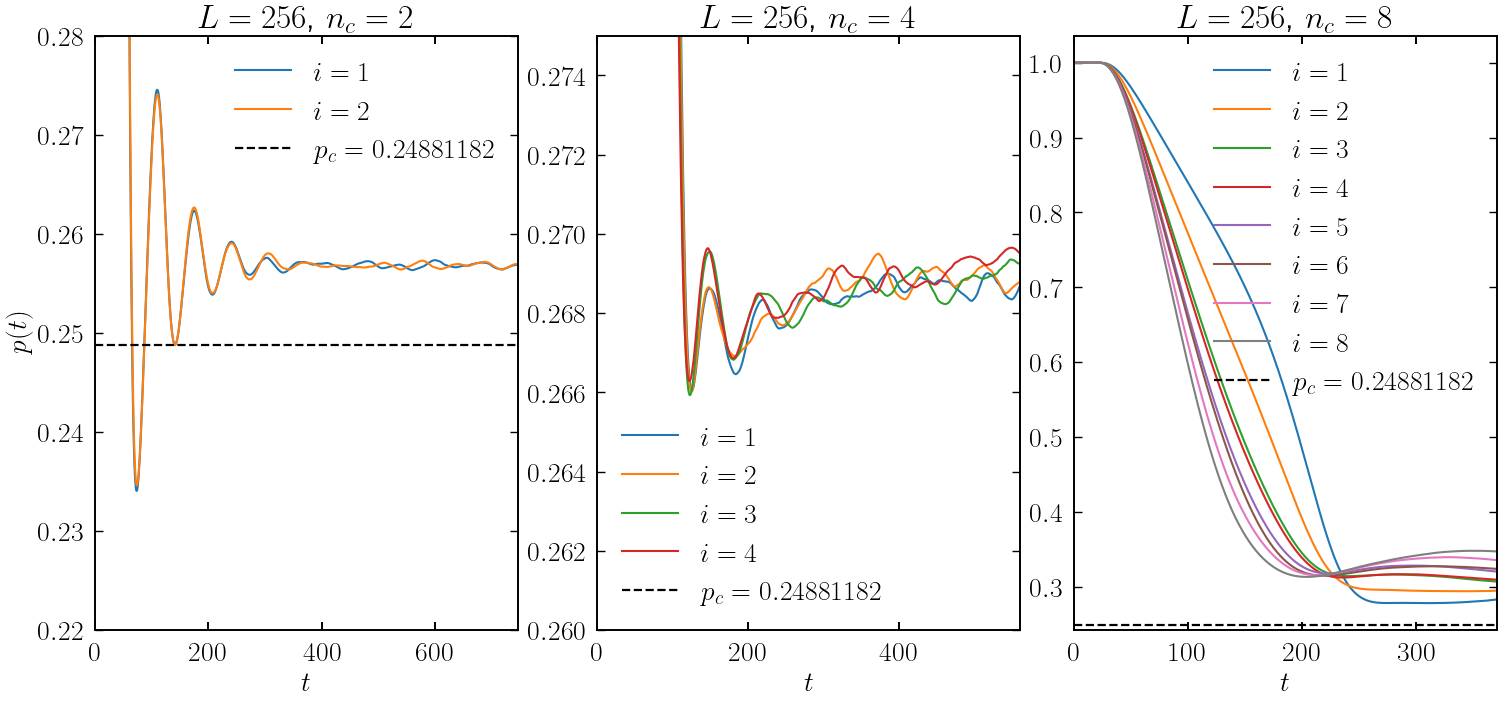

In [49]:
NC_LST = [2, 4, 8]
RHO_LST = [round(1/nc,2) for nc in NC_LST]
p0 = 1.0
L = 256

fig, axs = plt.subplots(1, 3, figsize=(15, 7), constrained_layout=True)
count = 0

for nc, rho in zip(NC_LST, RHO_LST):
    filename = f"../Data/bond_percolation/num_colors_{nc}/dim_3/L_{L}/NT_constant/NT_3000/k_1.0e-06/rho_{rho:.4e}/all_data_bundle.json"
    bundle, df = read_all_data_bundle(filename, as_dataframe=True)
    orders = df['order'].unique()
    x_max = 0
    for idx, ord in enumerate(orders):
        df_filter = df[df['order']==ord]
        axs[count].plot(df_filter['t'], df_filter['pt'],label=f'$i = {idx+1}$')
    
        if(x_max < max(df_filter['t'])):
            x_max = max(df_filter['t'])
        
    axs[count].set_title(f"$L = {L}$, $n_c = {nc}$")
    axs[count].set_xlim(0, int(x_max))
    axs[count].axhline(y=0.24881182,xmax=int(x_max),xmin=0, ls='--', lw='1.6', color='k' ,label=r'$p_c = 0.24881182$')
    count += 1

axs[0].set_ylim(0.22, 0.28)
axs[1].set_ylim(0.26, 0.275)

for ax in axs:
    ax.set_xlabel('$t$')
    
    ax.legend()
axs[0].set_ylabel('$p(t)$')
plt.savefig(results_folder + f"/pt_series_L_{L}_with_zoom.pdf")
plt.show()

In [138]:
df

,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
3174,512,3000,0.000001,2,0.011030,1.0,0.1,1,50,0.250182,0.000059,2850.780,29.863066,9539302.540,74998.156117
3175,512,3000,0.000001,2,0.011030,1.0,0.1,2,50,0.250117,0.000059,2955.000,24.991884,9540105.360,75031.676194
2872,512,3000,0.000001,2,0.013538,1.0,0.1,1,50,0.250046,0.000060,2803.360,28.682509,9373935.240,81298.242872
2873,512,3000,0.000001,2,0.013538,1.0,0.1,2,50,0.250218,0.000058,2899.700,27.087119,9374516.820,81230.615244
3082,512,3000,0.000001,2,0.016045,1.0,0.1,1,50,0.250156,0.000059,2891.320,27.316773,9633124.940,77766.680260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3363,128,3000,0.000001,2,0.497490,1.0,0.1,2,500,0.368663,0.000480,144.844,0.203219,992574.624,3070.589961
2542,256,3000,0.000001,2,0.500000,1.0,0.1,1,100,0.256731,0.000062,790.800,1.962631,3117258.750,5640.954449
3278,128,3000,0.000001,2,0.500000,1.0,0.1,1,500,0.556922,0.000929,144.390,0.165658,897404.110,2668.764902
2543,256,3000,0.000001,2,0.500000,1.0,0.1,2,100,0.256894,0.000067,798.020,1.846590,3117092.460,5648.742550


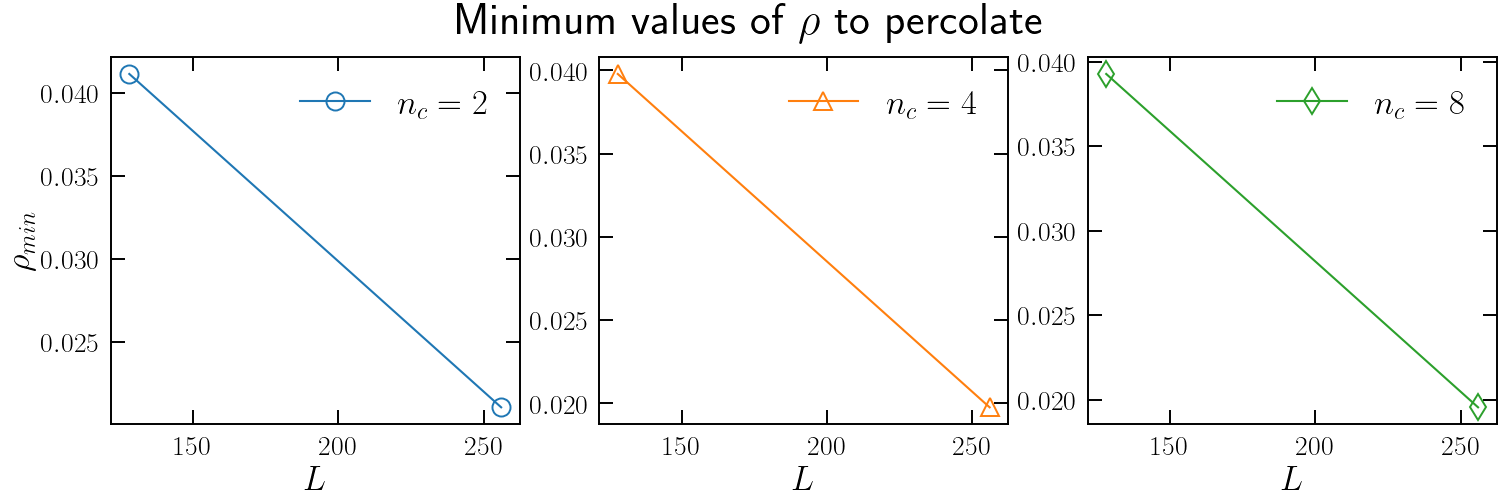

In [161]:
NC_LST = [2, 4, 8]
RHO_LST = [round(1/nc,2) for nc in NC_LST]
p0 = 1.0
L = [128, 256]
order = 1
rho_min_by_nc = {"nc":[], "L":[], "rho_min":[]}

fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
count = 0
for nc in NC_LIST:
    for l in L:
        df_filter = df[(df["L"]==l) & (df["nc"]==nc) & (df['order']==1)]
        rho_min = df_filter['rho'].min()
        
        rho_min_by_nc['nc'].append(nc)
        rho_min_by_nc['L'].append(l)
        rho_min_by_nc['rho_min'].append(rho_min)

df__ = pd.DataFrame(data=rho_min_by_nc)

markers = ["o", "^", "d"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
count =0
ms = 13
fontsize_labels = 25
fontsize_legend = 25
thickness_axes = 1.4

for nc, ax in zip(NC_LST, axs.flatten()):
    df_ = df__[df__["nc"] == nc]
    ax.plot(df_['L'], df_["rho_min"], marker=markers[count],ms = ms, mew=thickness_axes,
            color=colors[count], label=f'$n_c = {nc}$')
    ax.set_xlabel("$L$", fontsize = fontsize_labels)
    ax.legend(fontsize = fontsize_legend)
    count += 1
    
    ax.tick_params(axis='both', which='major', direction='in', length=10, width=thickness_axes, labelsize=20)
    for spine in ax.spines.values():
        spine.set_linewidth(thickness_axes)

fig.suptitle(r"Minimum values of $\rho$ to percolate", fontsize=32, fontweight='bold') # Adds a title to the entire figure
axs[0].set_ylabel(r'$\rho_{min}$', fontsize = fontsize_labels)
plt.show()
#print(rho_min_by_nc)

In [ ]:
)

for ax in axs:
    ax.set_xlabel('$t$')
    
    ax.legend()
axs[0].set_ylabel('$p(t)$')
plt.savefig(results_folder + f"/pt_series_L_{L}_without_zoom.pdf")
plt.show()
